In [3]:
# imports
import importlib
import download_data
importlib.reload(download_data)
from download_data import get_merged_data
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap
import holidays
import requests
import matplotlib.gridspec as gridspec
import optuna, warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from optuna.integration import XGBoostPruningCallback
import json, joblib, pathlib, datetime as dt, shutil
from functools import partial
from sklearn.metrics import mean_absolute_percentage_error
from pathlib import Path
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
# complete feature engineering
df = pd.DataFrame()
df = get_merged_data()

# create new features based on the kind of day like workday
at_holidays = holidays.Austria()

df["is_weekend"] = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"] = df["DateTime"].dt.date.map(at_holidays.__contains__).astype(int)
df["day_of_week"] = df["DateTime"].dt.weekday
df["dow"] = df["day_of_week"]  # alias for compatibility
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1
df['is_workday'] = (~df['is_weekend'] & ~df['is_holiday']).astype(int)
df["hour"] = df["DateTime"].dt.hour
df["quarter_hr"] = df["DateTime"].dt.minute // 15
df["month"] = df["DateTime"].dt.month

# encode cyclical time (24h)
seconds_in_day = 24 * 60 * 60
time_in_seconds = (
    df["DateTime"].dt.hour * 3600
    + df["DateTime"].dt.minute * 60
    + df["DateTime"].dt.second
)
df["time_sin"] = np.sin(2 * np.pi * time_in_seconds / seconds_in_day)
df["time_cos"] = np.cos(2 * np.pi * time_in_seconds / seconds_in_day)

# encode cyclical day of the year
DOY = df['DateTime'].dt.dayofyear
angle = 2 * np.pi * DOY / 365
df['doy_sin'] = np.sin(angle)
df['doy_cos'] = np.cos(angle)

# delete old dayahead columns
dayahead_cols = df.filter(like="DayAhead").columns
df = df.drop(columns=dayahead_cols)

# delete rows before 1.10.2018 (limits modell size and also no weather API for older data)
cutoff = pd.Timestamp("2018-10-01")
df = df[df["DateTime"] >= cutoff]

# delete all rows with NaNs and cut off incomplete tail
full_rows = ~df.isna().any(axis=1)
last_full_idx = full_rows[full_rows].index[-1]
df = df.loc[:last_full_idx]

# add lag features
lags = [1, 2, 3, 4, 8, 12, 24, 48, 96]
lag_cols = {f"load_lag_{lag}": df["Load_Actual"].shift(lag) for lag in lags}
df = pd.concat([df, pd.DataFrame(lag_cols)], axis=1)

# add differenced load features
df = df.assign(
    load_diff_1 = df["load_lag_1"] - df["load_lag_2"],
    load_diff_4 = df["load_lag_1"] - df["load_lag_4"],
    load_diff_24h = df["load_lag_1"] - df["load_lag_96"],
    diff_15m = df["Load_Actual"].diff(1),
)

# rolling statistics
df["load_mean_1h"] = df["Load_Actual"].rolling(4).mean()
df["load_std_1h"] = df["Load_Actual"].rolling(4).std()
df["load_ramp_1h"] = df["Load_Actual"].rolling(4).max() - df["Load_Actual"].rolling(4).min()
df["load_mean_3h"] = df["Load_Actual"].rolling(12).mean()
df["load_mean_12h"] = df["Load_Actual"].rolling(48).mean()
df["load_mean_24h"] = df["Load_Actual"].rolling(96).mean()

# multi-horizon targets
HORIZON = 96
target_cols = {f"target_t+{k}": df["Load_Actual"].shift(-k) for k in range(1, HORIZON + 1)}
df = pd.concat([df, pd.DataFrame(target_cols)], axis=1)

# force pandas to defragment underlying blocks
df = df.copy()

# delete NaNs after feature engineering
df = df.dropna().reset_index(drop=True)

# get start and end date for weather data
start_date = df["DateTime"].min().date()
end_date = df["DateTime"].max().date()

# example: coordinates for Vienna
latitude = 48.2082
longitude = 16.3738

# query weather data via API
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
    "timezone": "auto"
}
response = requests.get(url, params=params)
data = response.json()

# weather dataframe
hourly_data = data.get("hourly", {})
weather = pd.DataFrame(hourly_data)

# format weather time column
if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"])

# sort datetime columns
df = df.sort_values("DateTime")
weather = weather.sort_values("time")

# merge on datetime (left join: df ← weather)
df = pd.merge_asof(df, weather, left_on="DateTime", right_on="time", direction="bacMWard")

# drop weather time column
df = df.drop(columns=["time"])

# parameter for the curvature strength
p = 1.2  # 1 = linear, >1 = stronger increase at extreme values

# heating demand: stronger increase below 15 °C
df["heating_demand"] = df["temperature_2m"].apply(lambda t: (15 - t) ** p if t < 15 else 0)

# cooling demand: stronger increase above 22 °C
df["cooling_demand"] = df["temperature_2m"].apply(lambda t: (t - 22) ** p if t > 22 else 0)


In [ ]:
# clean up / final dataset
df = df.dropna().reset_index(drop=True)

# target & feature columns
target_cols  = [f"target_t+{k}" for k in range(1, HORIZON + 1)]
exclude      = {"DateTime", "Load_Actual", *target_cols}
feature_cols = [c for c in df.columns if c not in exclude]

X, y = df[feature_cols], df[target_cols]

# train / test split (time-order)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)

FOLDS = 4
GPU   = True

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int  ("n_estimators", 200, 600),  # gedeckelt
        "max_depth":        trial.suggest_int  ("max_depth",       3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample",     0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight",0.1, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma",           0, 5),
        "objective":        "reg:squarederror",
        "eval_metric":      "rmse",
        "random_state":     42,
        "n_jobs":           -1,
        "tree_method":      "hist",
        "device":           "cuda" if GPU else "cpu",
    }

    cv = TimeSeriesSplit(n_splits=FOLDS)
    rmses = []

    for tr_idx, va_idx in cv.split(X_tr):
        Xt, Xv = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        yt, yv = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]

        preds = []
        for h in range(yt.shape[1]):           # 96 Horizonte
            reg = XGBRegressor(
                **params,
                callbacks=[
                    EarlyStopping(rounds=30),
                    XGBoostPruningCallback(trial, "validation_0-rmse"),
                ],
            )
            reg.fit(Xt, yt.iloc[:, h],
                    eval_set=[(Xv, yv.iloc[:, h])],
                    verbose=False)
            preds.append(reg.predict(Xv))

        y_pred = np.column_stack(preds)
        rmses.append(np.sqrt(mean_squared_error(yv, y_pred)))

    return np.mean(rmses)

warnings.filterwarnings("ignore", message="The reported value is ignored.*")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner =optuna.pruners.MedianPruner(n_warmup_steps=5),
)

study.optimize(objective,
               n_trials=50,
               show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "objective":   "reg:squarederror",
    "eval_metric": "rmse",
    "n_jobs":      -1,
    "tree_method": "hist",
    "device":      "cuda" if GPU else "cpu",
})

# final model
base  = XGBRegressor(**best_params)
model = MultiOutputRegressor(base)
model.fit(X_tr, y_tr)

y_pred = pd.DataFrame(model.predict(X_te),
                      columns=target_cols, index=y_te.index)

rmse_h = np.sqrt(((y_te - y_pred) ** 2).mean())
mape_h = (np.abs((y_te - y_pred) / y_te).mean()) * 100
mae_h  = mean_absolute_error(y_te, y_pred, multioutput="raw_values")

print(f"Mean MAPE : {mape_h.mean():.2f}%")
print(f"Mean RMSE : {rmse_h.mean():.2f} MW")
print(f"Mean MAE  : {mae_h.mean():.2f} MW")

In [ ]:
# safe best multi-step-model
run_dir = pathlib.Path("run_" + dt.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
run_dir.mkdir(parents=True, exist_ok=True)

# save model and study
joblib.dump(model, run_dir / "best_xgb_multi.pkl")
joblib.dump(study, run_dir / "optuna_study.pkl")

# save test data and predictions
X_te.reset_index(drop=True).pipe(joblib.dump, run_dir / "X_te.pkl")
y_te.reset_index(drop=True).pipe(joblib.dump, run_dir / "y_te.pkl")
y_pred.reset_index(drop=True).pipe(joblib.dump, run_dir / "y_pred.pkl")

# save metrics
metrics = {
    "rmse_h": rmse_h.tolist(),
    "mape_h": mape_h.tolist(),
    "mae_h": mae_h.tolist(),
    "rmse_mean": float(rmse_h.mean()),
    "mape_mean": float(mape_h.mean()),
    "mae_mean": float(mae_h.mean()),
}
json.dump(metrics, open(run_dir / "metrics.json", "w"), indent=2)

best_path = pathlib.Path("best_run")

if best_path.is_symlink():
    best_path.unlink()
elif best_path.exists():
    shutil.rmtree(best_path)
try:
    best_path.symlink_to(run_dir, target_is_directory=True)
except Exception:
    shutil.copytree(run_dir, best_path)

print(f"Saved artifacts to: {run_dir.resolve()}")
print(f"Marked as best run: {best_path.resolve()}")

In [6]:
# load best multi-step-model and create baseline-model (t-96)
best_dir = pathlib.Path("best_run")
model  = joblib.load(best_dir / "best_xgb_multi.pkl")
study  = joblib.load(best_dir / "optuna_study.pkl")
X_te   = joblib.load(best_dir / "X_te.pkl")
y_te   = joblib.load(best_dir / "y_te.pkl")

with open(best_dir / "metrics.json") as f:
    metrics = json.load(f)

if isinstance(y_te, np.ndarray):
    y_te = pd.DataFrame(y_te, index=X_te.index)
elif isinstance(y_te, pd.Series):
    y_te = y_te.to_frame()

def _predict(model, X):
    try:
        return model.predict(X)
    except Exception:
        booster = model.get_booster() if hasattr(model, "get_booster") else model
        return booster.predict(xgb.DMatrix(X))

HORIZON = y_te.shape[1]
y_pred_arr = _predict(model, X_te)
if y_pred_arr.ndim == 1:
    y_pred_arr = y_pred_arr.reshape(-1, HORIZON)

y_pred_model = pd.DataFrame(y_pred_arr, index=y_te.index, columns=y_te.columns)

y_pred_baseline = y_te.shift(96)
mask = ~y_pred_baseline.isna().any(axis=1)
rmse_rolling = np.sqrt(mean_squared_error(y_te[mask], y_pred_baseline[mask]))
mape_rolling = mean_absolute_percentage_error(y_te[mask], y_pred_baseline[mask]) * 100

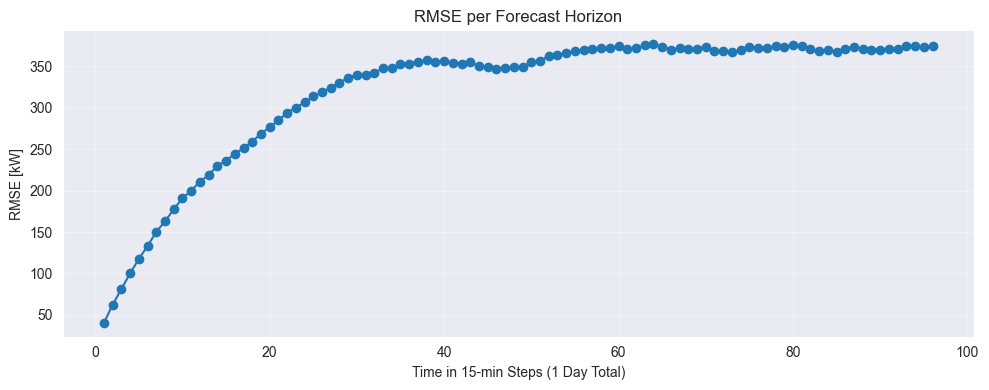

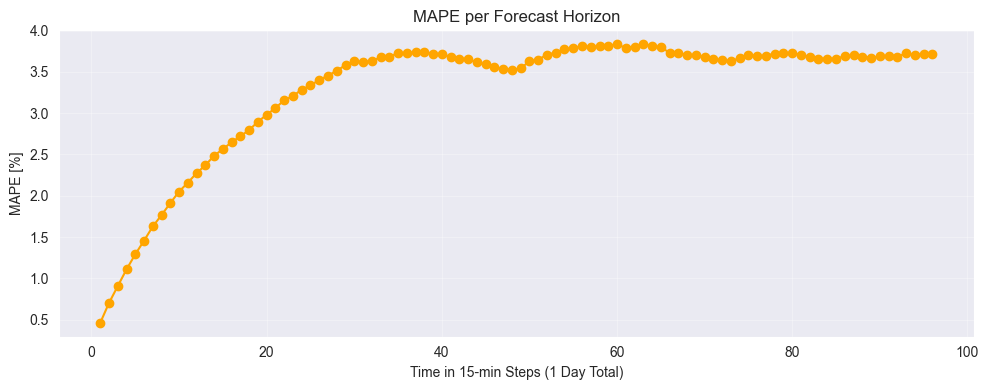

In [ ]:
# plot RMSE & MAPE per forecast horizon
best_dir = pathlib.Path("best_run")

rmse_vals = mape_vals = None
metrics_fp = best_dir / "metrics.json"

if metrics_fp.exists():
    with open(metrics_fp) as f:
        metrics = json.load(f)
    rmse_vals = np.asarray(metrics.get("rmse_h"))
    mape_vals = np.asarray(metrics.get("mape_h"))

horizons = np.arange(1, len(rmse_vals) + 1)

plt.figure(figsize=(10, 4))
plt.plot(horizons, rmse_vals, marker="o")
plt.title("RMSE per Forecast Horizon")
plt.xlabel("Time in 15-min Steps (1 Day Total)")
plt.ylabel("RMSE [MW]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(horizons, mape_vals, marker="o", color="orange")
plt.title("MAPE per Forecast Horizon")
plt.xlabel("Time in 15-min Steps (1 Day Total)")
plt.ylabel("MAPE [%]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


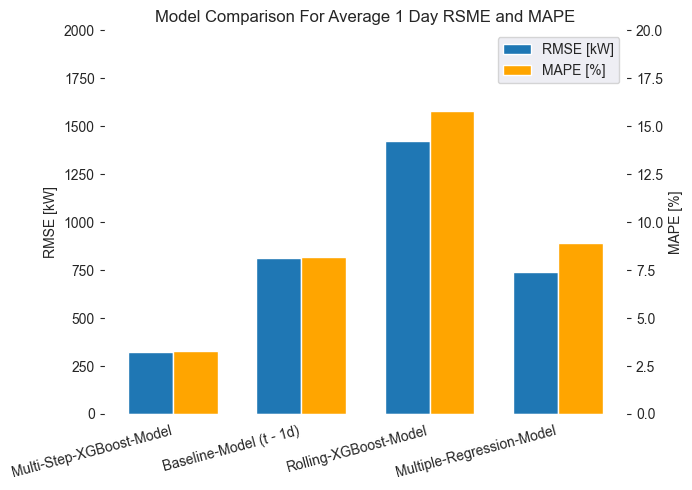

In [ ]:
# plot model comparison
best_dir = pathlib.Path("best_run")
with open(best_dir / "metrics.json") as f:
    base_metrics = json.load(f)

with open("rolling_metrics.json") as f:
    roll_metrics = json.load(f)[0]

mr_vals = {}
with open("multiple_regression_metrics", encoding="utf-8") as f:
    for line in f:
        key, val = line.split("=")
        mr_vals[key.strip()] = float(val)

models    = [
    "Multi-Step-XGBoost-Model",
    "Baseline-Model (t - 1d)",
    "Rolling-XGBoost-Model",
    "Multiple-Regression-Model"
]

rmse_vals = [
    base_metrics["rmse_mean"],
    rmse_rolling,
    roll_metrics["RMSE_total"],
    mr_vals["mr_RMSE"]
]

mape_vals = [
    base_metrics["mape_mean"],
    mape_rolling,
    roll_metrics["MAPE_total"],
    mr_vals["mr_MAPE"]
]

x, width = np.arange(len(models)), 0.35
fig, ax_rmse = plt.subplots(figsize=(7, 5))
ax_mape = ax_rmse.twinx()

ax_rmse.set_title("Model Comparison For Average 1 Day RSME and MAPE")

bars_rmse = ax_rmse.bar(x - width/2, rmse_vals, width)
bars_mape = ax_mape.bar(x + width/2, mape_vals, width, color="orange")

ax_rmse.set_ylabel("RMSE [MW]")
ax_mape.set_ylabel("MAPE [%]")

ax_rmse.set_ylim(0, 2000)
ax_mape.set_ylim(0, 20)

ax_rmse.set_xticks(x)
ax_rmse.set_xticklabels(models, rotation=15, ha="right")

ax_rmse.grid(False)
ax_mape.grid(False)
fig.patch.set_facecolor("white")
ax_rmse.set_facecolor("white")
ax_mape.set_facecolor("white")

ax_rmse.legend([bars_rmse[0], bars_mape[0]], ["RMSE [MW]", "MAPE [%]"])

plt.tight_layout()
plt.show()


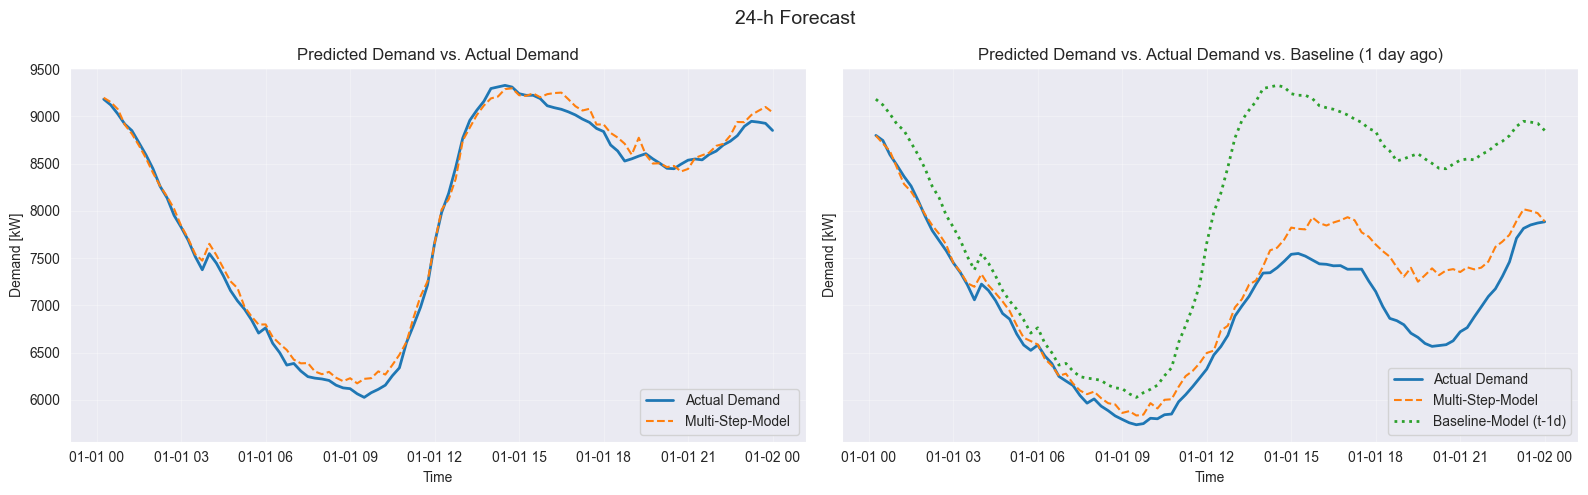

In [ ]:
# plotting predicted demand compared to actual demand
HORIZON = y_te.shape[1]
SHIFT   = 96
idx_earlier, idx_later = 0, SHIFT

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, idx, title in zip(
        axes,
        [idx_earlier, idx_later],
        ["Predicted Demand vs. Actual Demand",
         "Predicted Demand vs. Actual Demand vs. Baseline (1 day ago)"]):

    actual   = y_te.iloc[idx]
    model    = y_pred_model.iloc[idx]
    start_ts = pd.to_datetime(y_te.index[idx]) + pd.Timedelta(minutes=15)
    t_axis   = pd.date_range(start=start_ts, periods=HORIZON, freq="15min")

    ax.plot(t_axis, actual.values, label="Actual Demand", linewidth=2)
    ax.plot(t_axis, model.values,  label="Multi-Step-Model ",  linestyle="--")

    if idx == idx_later:
        baseline = y_pred_baseline.iloc[idx]
        ax.plot(t_axis, baseline.values, label="Baseline-Model (t-1d)",
                linestyle=":", linewidth=2)

    ax.set_xlabel("Time")
    ax.set_ylabel("Demand [MW]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")

fig.suptitle("24-h Forecast", fontsize=14)
fig.tight_layout()
plt.show()


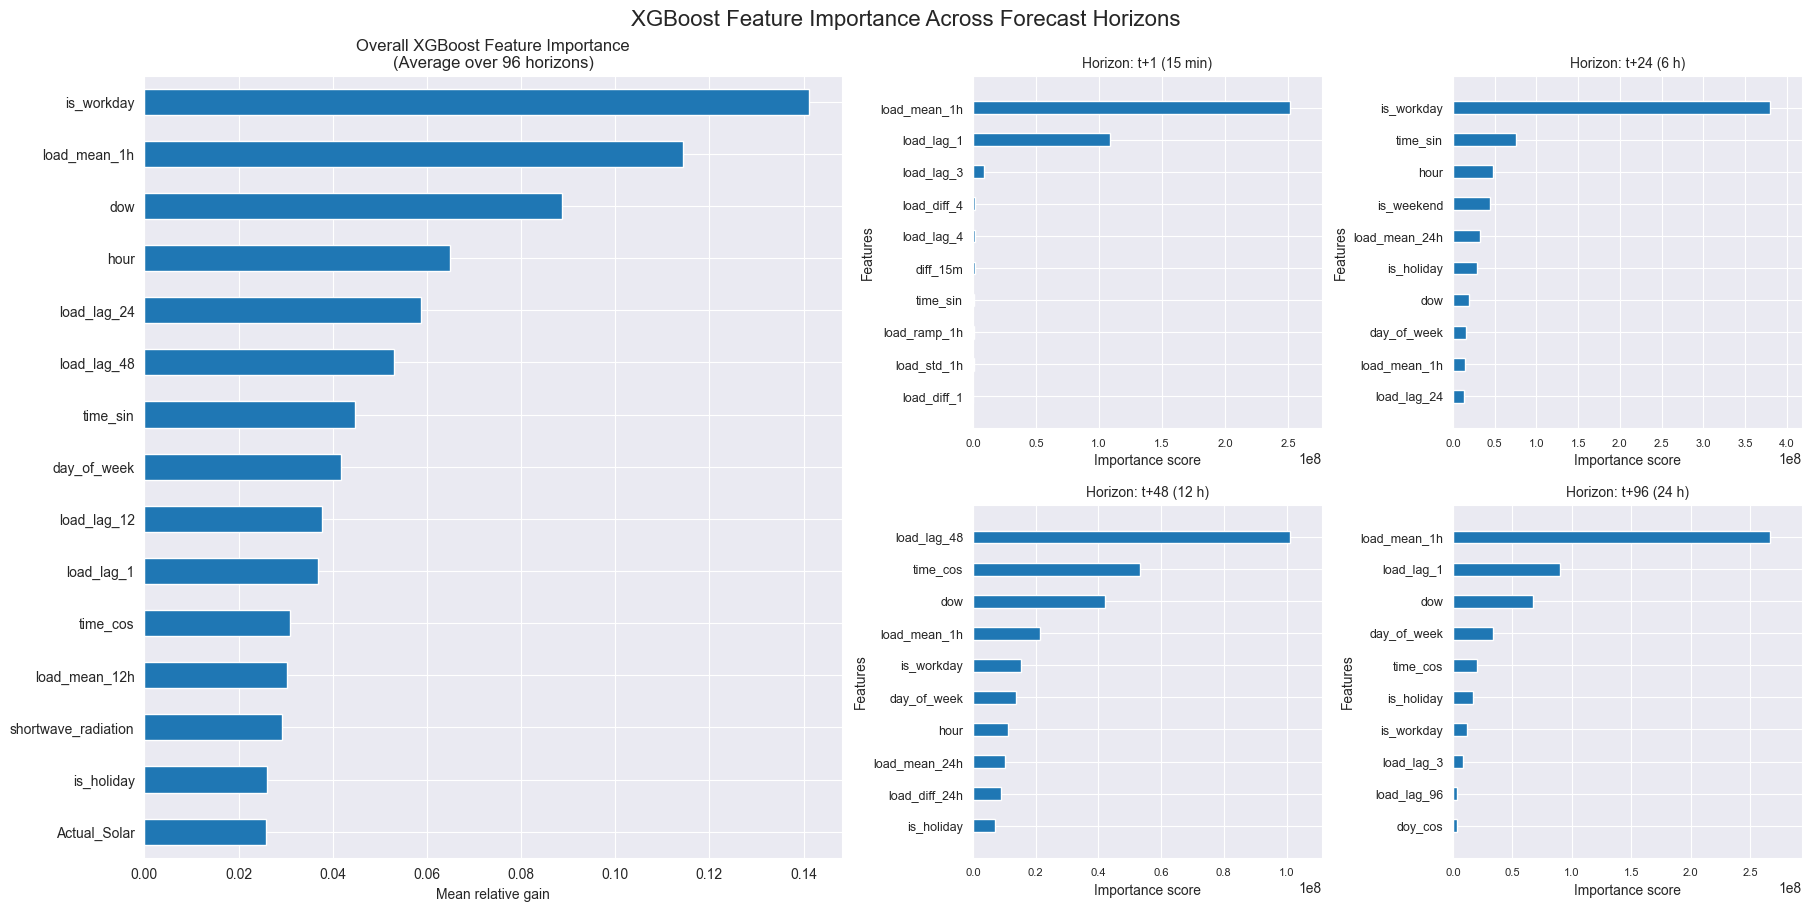

In [10]:
# feature importance for 1 day and how it develops over 96 x 15min time steps
best_dir = pathlib.Path("best_run")

if not isinstance(
        globals().get("model", None),
        (xgb.Booster, xgb.XGBModel, MultiOutputRegressor)):
    model = joblib.load(best_dir / "best_xgb_multi.pkl")

horizons = {"t+1 (15 min)": 0, "t+24 (6 h)": 23,
            "t+48 (12 h)": 47, "t+96 (24 h)": 95}

if isinstance(model, MultiOutputRegressor):
    boosters = [est.get_booster() for est in model.estimators_]
elif hasattr(model, "get_booster"):
    boosters = [model.get_booster()] * (max(horizons.values()) + 1)
elif isinstance(model, xgb.Booster):
    boosters = [model] * (max(horizons.values()) + 1)
else:
    raise TypeError("Variable `model` ist kein XGBoost-Modell.")

gain_rows = []
for bst in boosters:
    g = bst.get_score(importance_type="gain")
    s = sum(g.values()) or 1.0
    gain_rows.append({k: v / s for k, v in g.items()})

gain_df = pd.DataFrame(gain_rows).fillna(0.0)
top_k = gain_df.mean().sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(18, 9), constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[2, 1, 1])

ax_big = fig.add_subplot(gs[:, 0])
top_k[::-1].plot.barh(ax=ax_big)
ax_big.set_xlabel("Mean relative gain")
ax_big.set_title("Overall XGBoost Feature Importance\n(Average over 96 horizons)")

axes_small = [fig.add_subplot(gs[r, c]) for r in range(2) for c in (1, 2)]
for ax, (lbl, idx) in zip(axes_small, horizons.items()):
    xgb.plot_importance(boosters[idx], ax=ax,
                        max_num_features=10, height=0.4,
                        importance_type="gain", show_values=False)
    ax.set_title(f"Horizon: {lbl}", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("XGBoost Feature Importance Across Forecast Horizons", fontsize=16)
plt.show()

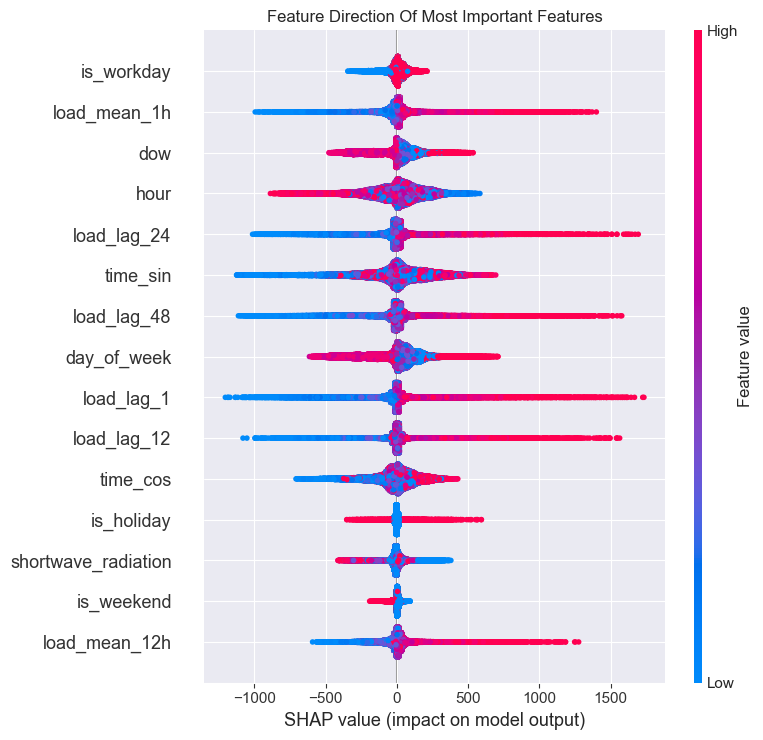

In [24]:
# feature direction of most important features
feat_map = {f"f{idx}": col for idx, col in enumerate(X_te.columns)}
gain_df  = pd.DataFrame([
    {feat_map.get(k, k): v for k, v in est.get_booster().get_score(importance_type="gain").items()}
    for est in model.estimators_
]).fillna(0)
top_feats = gain_df.mean(0).nlargest(15).index.tolist()

best_dir = Path("best_run"); best_dir.mkdir(exist_ok=True)
cache    = best_dir / "overall_shap_vals.pkl"
if cache.exists():
    shap_values_matrix, X_mat = joblib.load(cache)
else:
    X_bg  = shap.sample(X_te, 1000, random_state=0)
    X_ev  = shap.sample(X_te,  500, random_state=0)
    shap_values_matrix = np.vstack([
        shap.TreeExplainer(est, data=X_bg)(X_ev, check_additivity=False).values
        for est in model.estimators_
    ])
    X_mat = pd.concat([X_ev] * len(model.estimators_), ignore_index=True)
    joblib.dump((shap_values_matrix, X_mat), cache)

idx = [X_mat.columns.get_loc(f) for f in top_feats]
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_matrix[:, idx], X_mat[top_feats],
                  feature_names=top_feats, sort=False, max_display=len(top_feats), show=False)
plt.title("Feature Direction Of Most Important Features")
plt.tight_layout(); plt.show()


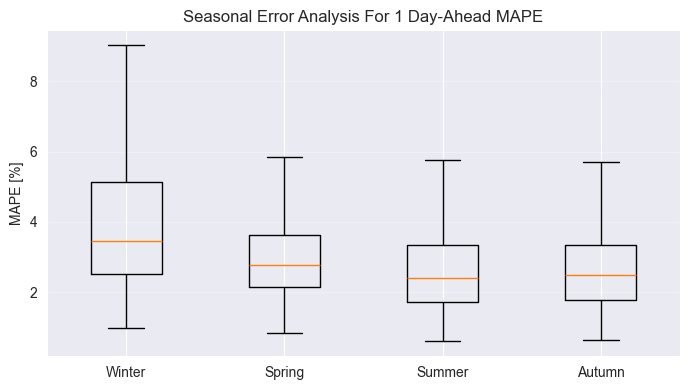

In [17]:
# Seasonal error analysis
timestamps = df.loc[y_te.index, "DateTime"] if "df" in globals() and "DateTime" in df.columns \
            else pd.to_datetime(y_te.index, errors="coerce")
season = timestamps.dt.month.replace({12:"Winter",1:"Winter",2:"Winter",
                                      3:"Spring",4:"Spring",5:"Spring",
                                      6:"Summer",7:"Summer",8:"Summer",
                                      9:"Autumn",10:"Autumn",11:"Autumn"})

mape_daily = (np.abs((y_te - y_pred_model) / y_te.replace(0, np.nan)).mean(axis=1) * 100)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
data = [mape_daily[season == s].dropna() for s in season_order]

plt.figure(figsize=(7, 4))
plt.boxplot(data, tick_labels=season_order, showfliers=False)
plt.ylabel("MAPE [%]")
plt.title("Seasonal Error Analysis For 1 Day-Ahead MAPE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



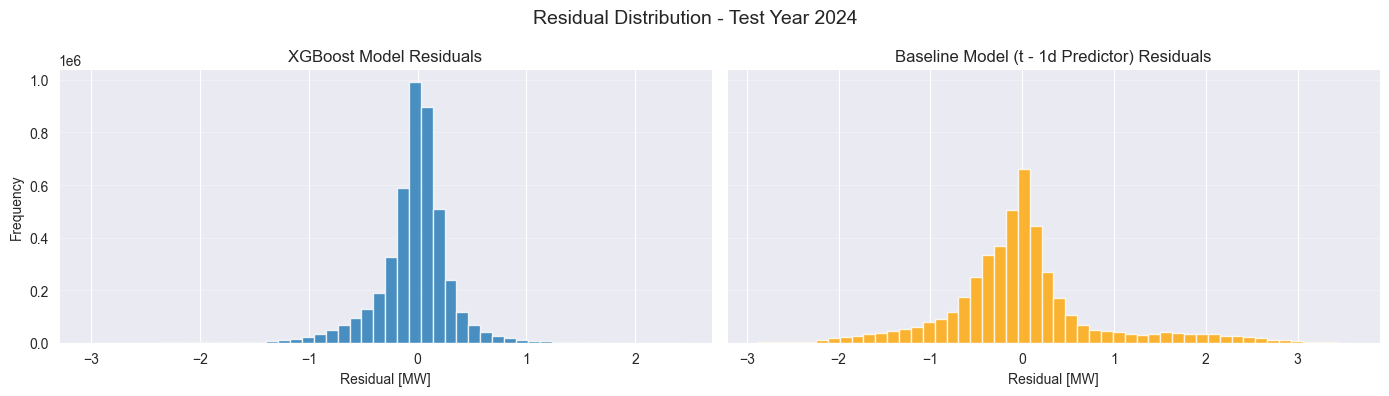

In [19]:
# Residual distribution – xgboost model vs. baseline model (1d ago)
SHIFT = 96

y_pred_baseline = y_te.shift(SHIFT, axis=0)

res_model = ((y_te - y_pred_model) / 1000).values.flatten()
res_base  = ((y_te - y_pred_baseline) / 1000).values.flatten()
res_base  = res_base[~np.isnan(res_base)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].hist(res_model, bins=50, alpha=0.8)
axes[0].set_title("XGBoost Model Residuals")
axes[0].set_xlabel("Residual [MW]")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(res_base, bins=50, alpha=0.8, color="orange")
axes[1].set_title("Baseline Model (t - 1d Predictor) Residuals")
axes[1].set_xlabel("Residual [MW]")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Residual Distribution - Test Year 2024", fontsize=14)
fig.tight_layout()
plt.show()
